# In-Class Assignment 9

## Stellar Energy Sources

### Learning Objectives

- explore thermonuclear burning in various stellar models
- identify the dominant burning sources in stars during H-burning 
- compare crossover times in dominant burning categories
- visualizing main-sequence stellar models using `tulips`

To produce plots in the optional exercises we will use [mesaplot](https://github.com/rjfarmer/mesaplot) and [Tulips - _A Tool for Understanding the Lives, Interiors, and Physics of Stars_](https://astro-tulips.readthedocs.io/en/latest/index.html) and the Paper [here](https://www.sciencedirect.com/science/article/pii/S2213133721000688?via%3Dihub). Install each by performing the following commands to install them using `pip`:


[**mesaPlot**](https://github.com/rjfarmer/mesaplot)

````{note}
`mesaplot` is not available on PyPI, so it can be installed using `pip` as:
```
pip install git+https://github.com/rjfarmer/mesaplot
```
````

[**Tulips** Installation](https://astro-tulips.readthedocs.io/en/latest/installation.html)

````{note}
`py_mesa_reader` is not available on PyPI, so it can be installed using `pip` as:
```
pip install astro-tulips
```
````

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# only uncomment if you were able to successfully install
import tulips

# note the capital `P`
import mesaPlot as mp

### only try below if imports above to not work
##import sys 
# you may have to run the below, try importing without first
# this will be different for you, find its location using `pip show mesaplot`
## sys.path.append('/opt/anaconda3/lib/python3.11/site-packages/mesaPlot') 

## a. Thermonuclear Burning Accross Mass Ranges

Download the following model files locally:

* $1 M_\odot$: [1m_h_dep_history.data](data/1m_h_dep_history.data);

* $3 M_\odot$: [3m_h_dep_history.data](data/3m_h_dep_history.data);

* $20 M_\odot$: [20m_he_dep_history.data](data/20m_he_dep_history.data);


Then, using the $1 M_\odot$ and $3M_\odot$ model MESA history data: 

1. Plot the log nuclear energy generation rate ($\epsilon_{\rm{nuc}}$) for the `pp` and `cno` burning categories as a function of the `model_number` (x-axis) to determine which dominates in each model. 

> Note: The variables `pp` and `cno` are $\rm{log}_{10}(\epsilon_{\rm{nuc,pp}})$ etc. 

2. To help guide follow the temporal evolution, also plot the `center_h1` as a function of model number for both models on the same plot and _label_.

> Set your ylim to (-2,) - when you leave the upper limit unset it will auto set the ymax. 

3. Identify the approximate `model_number` where the dominant burning crossover occurs for the $3M_{\odot}$ model and plot a vertical line (`plt.axvline`) denoting this on the same plot. 

4. On a **new** plot, plot $\textrm{log}~(\epsilon_{\rm{nuc}}/\rho X^2)$ as a function of the central $T_{6,c}$ ($T_{c}/T^{6}\rm{K}$). 

> Hint: Set xlim to (5,30) and ylim to (-6,6)

5. On this plot, plot the approximate central $T_{6}$ where the `CNO` burning category begins to dominate and label using `plt.axvline`.

6. Lastly, print the central $T_{6}$ at the model number for the $3M_{\odot}$ model found for the crossover in part 3. Do they match?

7. In a few sentences, describe the dominant burning category for the 1M model and 3M models based off these two plots. 

> Hint: Compare with HKT Figure 6.10!

In [2]:
## load MESA data here
one_m_ms_history = pd.read_csv('data/1m_h_dep_history.data',sep=r'\s+',header=4)
three_m_ms_history = pd.read_csv('data/3m_h_dep_history.data',sep=r'\s+',header=4)
list(one_m_ms_history)

['model_number',
 'num_zones',
 'star_age',
 'log_dt',
 'star_mass',
 'log_xmstar',
 'log_abs_mdot',
 'mass_conv_core',
 'conv_mx1_top',
 'conv_mx1_bot',
 'conv_mx2_top',
 'conv_mx2_bot',
 'mx1_top',
 'mx1_bot',
 'mx2_top',
 'mx2_bot',
 'log_LH',
 'log_LHe',
 'log_LZ',
 'log_Lnuc',
 'eps_grav_integral',
 'pp',
 'cno',
 'tri_alpha',
 'eps_nuc_rate_r34_pp2',
 'eps_nuc_rate_r34_pp3',
 'eps_nuc_rate_r_c12_ag_o16',
 'eps_nuc_rate_r_h1_he3_wk_he4',
 'eps_nuc_rate_r_he3_he3_to_h1_h1_he4',
 'eps_nuc_rate_r_he4_he4_he4_to_c12',
 'eps_nuc_rate_r_ne20_ag_mg24',
 'eps_nuc_rate_r_o16_ag_ne20',
 'eps_nuc_rate_rbe7ec_li7_aux',
 'eps_nuc_rate_rbe7pg_b8_aux',
 'eps_nuc_rate_rc12_to_n14',
 'eps_nuc_rate_rc12ap_aux',
 'eps_nuc_rate_rc12ap_to_o16',
 'eps_nuc_rate_rf19pa_aux',
 'eps_nuc_rate_rf19pg_aux',
 'eps_nuc_rate_rn14_to_c12',
 'eps_nuc_rate_rn14_to_o16',
 'eps_nuc_rate_rn14ag_lite',
 'eps_nuc_rate_rn14pg_aux',
 'eps_nuc_rate_rn15pa_aux',
 'eps_nuc_rate_rn15pg_aux',
 'eps_nuc_rate_rna23pa_aux',
 'eps

In [3]:
# load one m burning info here
one_m_ms_model_number = one_m_ms_history['model_number'] # model number
one_m_ms_pp = 10**(one_m_ms_history['pp']) # eps_nuc due to pp chains
one_m_ms_cno = 10**(one_m_ms_history['cno']) # eps_nuc due to cno chains
one_m_ms_h1 = one_m_ms_history['center_h1'] # h1 mass fraction

# load three m burning info here
three_m_ms_model_number = three_m_ms_history['model_number'] # model number
three_m_ms_pp = 10**(three_m_ms_history['pp']) # eps_nuc due to pp chains
three_m_ms_cno = 10**(three_m_ms_history['cno']) # eps_nuc due to cno chains
three_m_ms_h1 = three_m_ms_history['center_h1'] # h1 mass fraction

Text(0, 0.5, '$\\rm{log}_{10} (\\epsilon_{\\rm{nuc}}) \\ (\\rm{erg \\ g}^{-1} \\ \\rm{s}^{-1})$')

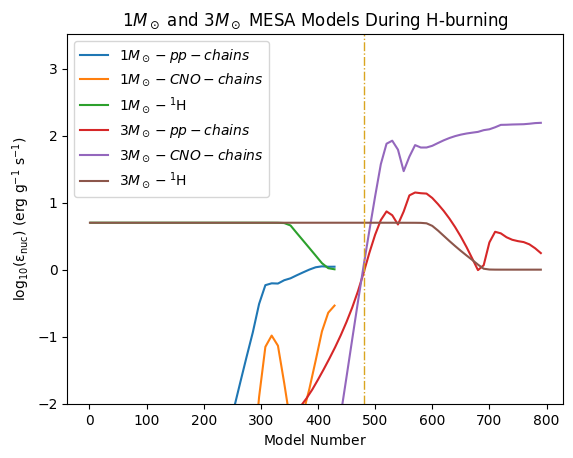

In [4]:
## 1-3 result here
plt.title('1$M_\odot$ and 3$M_\odot$ MESA Models During H-burning')

plt.plot(one_m_ms_model_number,
         np.log10(one_m_ms_pp),label=r'$1M_\odot - pp-chains$')

plt.plot(one_m_ms_model_number,
         np.log10(one_m_ms_cno),label=r'$1M_\odot - CNO-chains$')

plt.plot(one_m_ms_model_number,
         one_m_ms_h1,label=r'$1M_\odot - ^{1}\rm{H}$')


plt.plot(three_m_ms_model_number,
         np.log10(three_m_ms_pp),label=r'$3M_\odot - pp-chains$')

plt.plot(three_m_ms_model_number,
         np.log10(three_m_ms_cno),label=r'$3M_\odot - CNO-chains$')

plt.plot(three_m_ms_model_number,
         three_m_ms_h1,label=r'$3M_\odot - ^{1}\rm{H}$')

plt.axvline(480,lw=1,color='goldenrod',ls='-.')

plt.ylim(-2,)
#plt.xlim(0,)

plt.legend()
plt.xlabel(r'$\rm{Model \ Number}$')
plt.ylabel(r'$\rm{log}_{10} (\epsilon_{\rm{nuc}}) \ (\rm{erg \ g}^{-1} \ \rm{s}^{-1})$')

In [5]:
# load central rho and T here
one_m_ms_center_T = 10**(one_m_ms_history['log_center_T']) # central T
three_m_ms_center_T = 10**(three_m_ms_history['log_center_T']) # central T

one_m_ms_center_rho = 10**(one_m_ms_history['log_center_Rho']) # central T
three_m_ms_center_rho = 10**(three_m_ms_history['log_center_Rho']) # central T

Text(0.5, 0, '$T_{6,\\rm{central}}$')

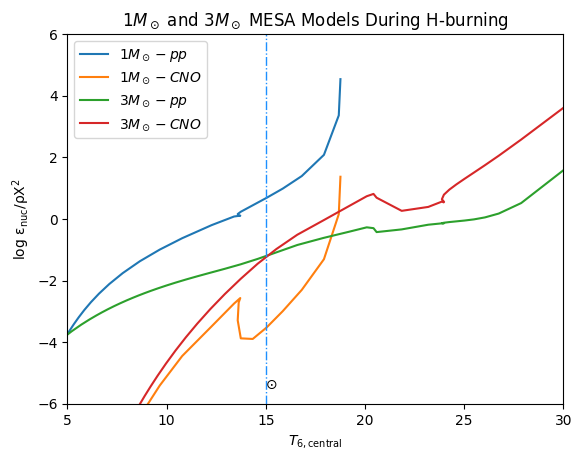

In [7]:
## 4 result here
plt.title('1$M_\odot$ and 3$M_\odot$ MESA Models During H-burning')

plt.plot(one_m_ms_center_T/1e6,
         np.log10(one_m_ms_pp/(one_m_ms_h1*one_m_ms_h1)),label=r'$1M_\odot - pp$')

plt.plot(one_m_ms_center_T/1e6,
         np.log10(one_m_ms_cno/(one_m_ms_center_rho*one_m_ms_h1*one_m_ms_h1)),label=r'$1M_\odot - CNO$')


plt.plot(three_m_ms_center_T/1e6,
         np.log10(three_m_ms_pp/(three_m_ms_center_rho*three_m_ms_h1*three_m_ms_h1)),label=r'$3M_\odot - pp$')

plt.plot(three_m_ms_center_T/1e6,
         np.log10(three_m_ms_cno/(three_m_ms_center_rho*three_m_ms_h1*three_m_ms_h1)),label=r'$3M_\odot - CNO$')


# approximate present location of the Sun
plt.text(15, -5.5, "⊙")

plt.axvline(15,color='dodgerblue',lw=1,ls='-.')

plt.ylim(-6,6)
plt.xlim(5,30)

plt.legend()
plt.ylabel(r'$\rm{log}~\epsilon_{\rm{nuc}}/\rho X^2$')
plt.xlabel(r'$T_{6,\rm{central}}$')

In [8]:
# compute approximate crossover temperature here
crossover_index = np.where(three_m_ms_history['model_number']==480)[0]
print(crossover_index,three_m_ms_center_T[crossover_index]/1e6)

[48] 48    15.530275
Name: log_center_T, dtype: float64


> In a few sentences, describe the dominant burning category for the 1M model and 3M models based off these two plots. Does the approximate crossover point match your estimates from Plot 1 and 2? 

Your thoughtful answer here.

## b. Thermonuclear Burning In a Massive Star

Using the $20M_\odot$ model MESA history data (`20m_he_dep_history.data`):

1. Plot the log nuclear energy generation rate ($\epsilon_{\rm{nuc}}$) for the `pp` and `cno` burning categories as a function of the `model_number` (x-axis) to determine which dominates in each model. 

> Set your xlim to (370,600) to focus on the main-sequency

2. To help guide follow the temporal evolution, also plot the `center_h1` as a function of model number for both models on the same plot and _label_.

> Are there any crossover points observed in this model between dominant burning categories?

3. Plot $\textrm{log}~(\epsilon_{\rm{nuc}}/\rho X^2)$ as a function of the central $T_{6,c}$ ($T_{c}/T^{6}\rm{K}$) for both categories.

> Hint: set xlim to (30,100)

4. Conclude the dominant burning source on the main-sequence and state if there are any crossover points in a few words.


In [9]:
# load 20m data
twenty_m_ms_history = pd.read_csv('data/20m_he_dep_history.data',sep=r'\s+',header=4)
twenty_m_ms_model_number = twenty_m_ms_history['model_number'] # model number
twenty_m_ms_pp = 10**(twenty_m_ms_history['pp']) # eps_nuc due to pp chains
twenty_m_ms_cno = 10**(twenty_m_ms_history['cno']) # eps_nuc due to cno chains
twenty_m_ms_h1 = twenty_m_ms_history['center_h1'] # h1 mass fraction

Text(0, 0.5, '$\\epsilon_{\\rm{nuc}} \\ (\\rm{erg \\ g}^{-1} \\ \\rm{s}^{-1})$')

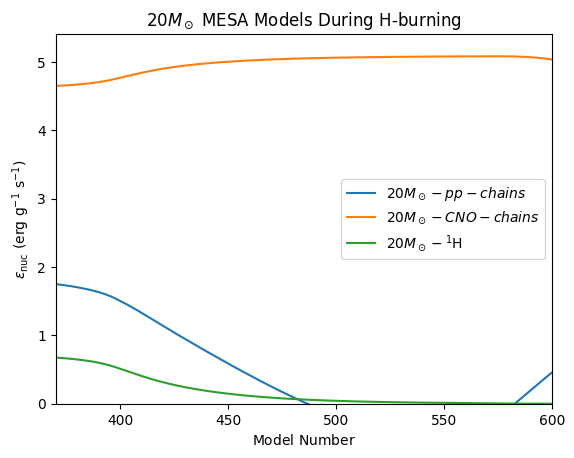

In [10]:
## 1-3 result here
plt.title('20$M_\odot$ MESA Models During H-burning')

plt.plot(twenty_m_ms_model_number,
         np.log10(twenty_m_ms_pp),label=r'$20M_\odot - pp-chains$')

plt.plot(twenty_m_ms_model_number,
         np.log10(twenty_m_ms_cno),label=r'$20M_\odot - CNO-chains$')

plt.plot(twenty_m_ms_model_number,
         twenty_m_ms_h1,label=r'$20M_\odot - ^{1}\rm{H}$')

plt.ylim(0,)
plt.xlim(370,600)

plt.legend()
plt.xlabel(r'$\rm{Model \ Number}$')
plt.ylabel(r'$\epsilon_{\rm{nuc}} \ (\rm{erg \ g}^{-1} \ \rm{s}^{-1})$')

In [11]:
twenth_m_ms_center_T = 10**(twenty_m_ms_history['log_center_T']) # central T
twenty_m_ms_center_rho = 10**(twenty_m_ms_history['log_center_Rho']) # central T

Text(0.5, 0, '$T_{6,\\rm{central}}$')

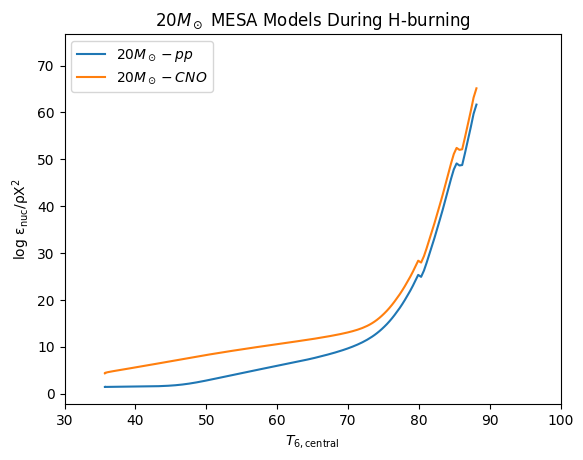

In [12]:
## 4 result here
plt.title('20$M_\odot$ MESA Models During H-burning')

plt.plot(twenth_m_ms_center_T/1e6,
         np.log10(twenty_m_ms_pp/(twenty_m_ms_center_rho*twenty_m_ms_h1*twenty_m_ms_h1)),label=r'$20M_\odot - pp$')

plt.plot(twenth_m_ms_center_T/1e6,
         np.log10(twenty_m_ms_cno/(twenty_m_ms_center_rho*twenty_m_ms_h1*twenty_m_ms_h1)),label=r'$20M_\odot - CNO$')


plt.xlim(30,100)

plt.legend()
plt.ylabel(r'$\rm{log}~\epsilon_{\rm{nuc}}/\rho X^2$')
plt.xlabel(r'$T_{6,\rm{central}}$')

## c. (Optional!) Visualizing the Main-Sequence using Tulips

Import `tulips` and `mesaPlot` here if you did not import above and then:


Download this $1M_{\odot}$ model evolved from MS to this H-shell burning phase:

* $1 M_\odot$: [1m_thermohaline_history.data](data/1m_thermohaline_history.data);

1. Create a folder in your `data` directory or anywhere really, named `tulips` and **copy** your `1m_thermohaline_history.data` into the directory and rename it as `history.data`.

2. Then set your directory path for tulips. It will look in this directory for a file called `history.data`.

3. Create your data object for analysis using `mesaPlot`: 

```
m1 = mp.MESA()
```

4. Load the history data using this object:

```
m1.loadHistory(f=`YOUR_PATH_NAME`)
```

5. Now, using `tulips` to produce an `energy_and_mixing` plot using your history data. It will create a series of these plots based on your defined step size `N`.

6. Lastly, open and view the plot, can you identify where the model is convective or radiative on the main-sequence?

7. (Bonus), Can you see when are where the model experiences thermohaline/double diffusive mixing?

In [13]:
## 1- 4 here
SINGLE_M1_DIR = "./data/tulips/20m"

m1 = mp.MESA()
m1.loadHistory(f=SINGLE_M1_DIR)
N = 1

  0%|          | 0/102 [00:00<?, ?it/s]

Creating movie...


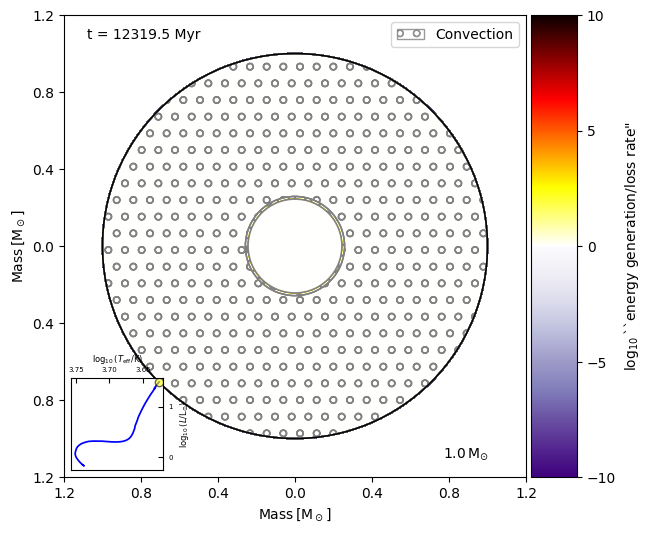

In [14]:
# compute and plot the viz
tulips.energy_and_mixing(m1, time_ind=(0,-1, N), fps=10, fig_size=(8,6),
                         show_total_mass=True,show_hrd_ticks_and_labels=True, show_mix=True, show_mix_legend=True, 
                         output_fname="energy_and_mixing")
plt.show()

In [15]:
# open and watch the visualization here
from IPython.display import Video

Video("energy_and_mixing.mp4", embed=True, width=700, height=600)

Your thoughtful response to 6 (and 7 possibly) here.